# Functions

## What are functions?

Functions are reusable blocks of code that perform a specific task. They help streamline your code by allowing you to avoid repetition, improve readability, and make maintenance easier.

The general syntax for defining a function is the following:

```python
def function_name(parameter_1, ..., parameter_n):
    """Docstring"""
    <body of the function>
    return value  # Depending on the function
```

In [15]:
# Example 1: one-line docstring, no parameters, no return value
def greet():
    """Print a greeting message."""
    print("Hello, welcome to the class!")

In [16]:
# Example 2: multi-line docstring, parameters, and return value
def calculate_area(radius):
    """
    Calculate the area of a circle given its radius.
    
    Args:
        radius (float): The radius of the circle.
        
    Returns:
        float: The area of the circle, calculated as π * radius^2.
    """
    area = 3.14159 * radius ** 2
    return area

## Data loading and preparation

We'll practice creating functions using the same datasets from last week.

In [17]:
import os
import pandas as pd

import geopandas as gpd
import matplotlib.pyplot as plt

# Display all columns when looking at dataframes
pd.set_option("display.max.columns", None)

# --------------------------------------------------
# Import power plants data
URL = 'https://raw.githubusercontent.com/carmengg/eds-220-book/refs/heads/main/data/power_plants_epsg4269.csv'
power_plants = pd.read_csv(URL)
power_plants = power_plants.drop(columns='Unnamed: 0') # Drop first column

# Import states data
fp = os.path.join('data','tl_2022_us_state','tl_2022_us_state.shp')
states = gpd.read_file(fp)
states.columns = states.columns.str.lower()

# --------------------------------------------------
# Create geometry column for power plants
points = gpd.points_from_xy(power_plants.longitude,
                            power_plants.latitude)

# Convert power plants DataFrame to GeoDataFrame
power_plants = gpd.GeoDataFrame(power_plants,      # Data
                                geometry=points,   # Specify geometry column
                                crs='EPSG:4269'    # Specify CRS
                                )


## Exercise: CA top power plant sources map

Last week we solved the followinge exercise to use a `for` with a `zip` to create subplots of the top 3 power plant sources in California.

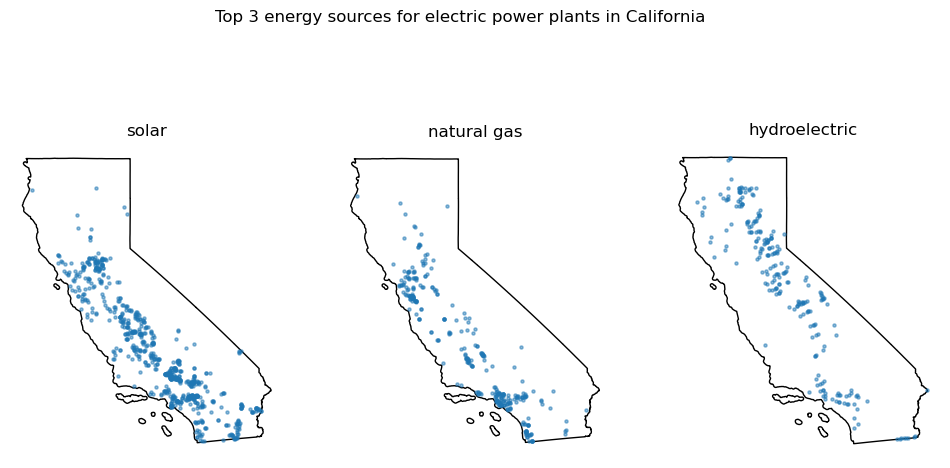

In [18]:
# Select CA power plants and boundary
ca_power_plants = power_plants[power_plants['state'] == 'California']
ca_boundary = states[states['name'] == 'California']

# CA top 3 power sources were previously given
ca_top_sources = ['solar', 'natural gas', 'hydroelectric']

# Create subplots for each top source in a single figure
fig, ax = plt.subplots(figsize=(12,6), nrows=1, ncols=3)
for axis, source in zip(ax, ca_top_sources):   # Iterate over subplots and energy sources

    axis.set_title(source)
    axis.axis('off')

    ca_boundary.plot(ax=axis,
                     color='none')
    
    # Subset power plants by source and plot
    source_subset = ca_power_plants[ca_power_plants['primsource'] == source]
    source_subset.plot(ax=axis,
                    markersize=5,
                    alpha=0.5)

plt.suptitle(f"Top 3 energy sources for electric power plants in California")    
plt.show()

# Write a function to do this for any state

### Step 1: Find top sources for a state

In [19]:
def find_top3(state, power_plants):
    # Assert error if input not in power_plants state column
    assert (power_plants['state'] == state).any(), f'{state} is not in power_plants data'
    
    # Assign filtered dataframe
    state_power_plants = power_plants[power_plants['state'] == state]
    
    top3 = state_power_plants['primsource'].value_counts().head(3).index.to_list()
    
    return top3
    

### Step 2: Plot the top 3 sources

In [20]:
def state_primsources(state, sources, power_plants):
    # Assert error if input not in power_plants state column
    assert (power_plants['state'] == state).any(), f'{state} is not in power_plants data'
    # Assert error if sources is not length 3
    assert len(sources) == 3, f'Sources list is not length 3'
    
    # Isolate state power plants
    state_data = power_plants[power_plants['state'] == state]
    # Isolate sources of interest within state
    state_sources = state_data[state_data['primsource'].isin(sources)]
    
    # Isolate state boundary from states data
    state_boundary = states[states['name'] == state]
    
    fig, ax = plt.subplots(figsize=(12, 6), nrows=1, ncols=3)

    for ax, source in zip(ax, sources):
    
        ax.set_title(source)
    
        ax.axis('off')
        
        state_boundary.boundary.plot(ax=ax, edgecolor='black')
        state_sources[state_sources['primsource'] == source].plot(ax=ax, markersize=0.7, c='green')
    

    fig.suptitle(f"Top 3 Energy Sources for Power Plants in {state}, USA", fontsize=15, y = 0.95)
    plt.show()

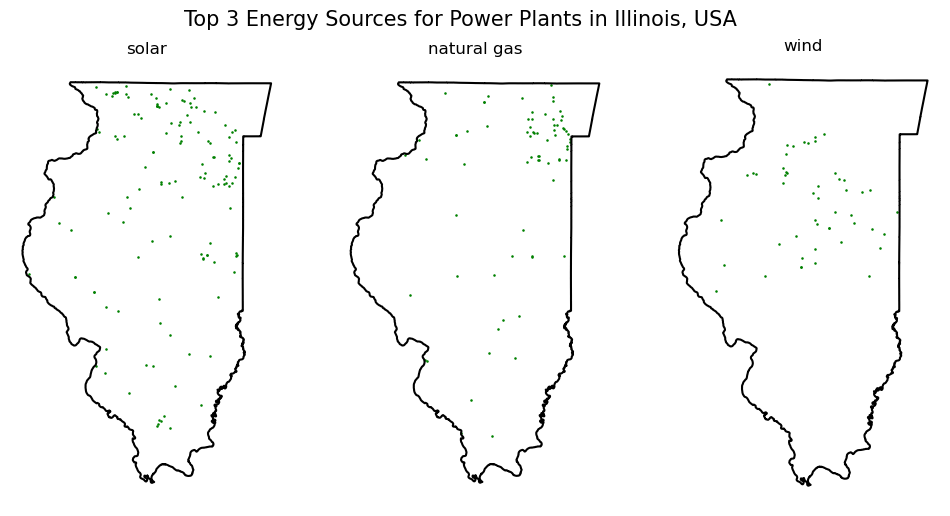

In [21]:
state_primsources('Illinois', find_top3('Illinois', power_plants), power_plants)

## Class Exercise 1
Create a function called power_source_counts that, given a power source, returns a Series with the counts of power plants by state that use that source.

In [22]:
def power_source_counts(source, power_plants):
    assert (power_plants['primsource'] == source).any(), f'{source} is not found in data.'
    # Filter to only specified source
    source_only = power_plants[power_plants['primsource'] == source]
    
    # Find unique state values
    state_list = source_only.groupby('state').size().sort_values(ascending=False).rename(f'n_{source.replace(" ", "_")}_plants')
    
    return state_list
    

In [23]:
power_source_counts('solar', power_plants)

state
California              766
North Carolina          728
Massachusetts           467
Minnesota               462
New York                396
New Jersey              279
Florida                 137
Illinois                133
Colorado                129
Texas                   126
Maryland                125
Georgia                 124
Oregon                  113
South Carolina          106
Indiana                  91
Arizona                  88
New Mexico               76
Virginia                 71
Connecticut              59
Rhode Island             55
Vermont                  49
Nevada                   47
Michigan                 46
Wisconsin                43
Pennsylvania             42
Utah                     41
Maine                    37
Ohio                     35
Hawaii                   28
Tennessee                25
Missouri                 24
Arkansas                 21
Puerto Rico              16
Iowa                     15
Delaware                 13
Nebraska      

## Class Exercise 2
Create a function that returns a map of the top3 states that use a power source.

In [66]:
def top3_states(source):
    # Assert error if input not in power_plants state column
    assert source in power_plants['primsource'].values, f'{source} is not in power_plants data'
    
    # Assign specified source dataframe
    source_only = power_plants[power_plants['primsource'] == source]
    
    # Find counts
    counts = source_only['state'].value_counts().head(3)
    
    # Assign top 3s
    top3_states = counts.index.to_list()
    top3_counts = counts.values.tolist()
    
    fig, axes = plt.subplots(figsize=(12, 6), nrows=1, ncols=3)

    for ax, state, count in zip(axes, top3_states, top3_counts):
        
        # Subset state boundary
        subset_boundary = states[states['name'] == state]
        
        # Subset powerplants to state
        subset_powerplants = source_only[source_only['state'] == state]
    
        ax.set_title(f'{state} ({count} power plants)')
    
        ax.axis('off')
        
        subset_boundary.boundary.plot(ax=ax, edgecolor='black')
        
        subset_powerplants[subset_powerplants['primsource'] == source].plot(ax=ax, markersize=7, c='hotpink')
        
    fig.suptitle(f"Top 3 States by Number of {source.capitalize()} Powered Electric Plants", fontsize=15, y=1)
    plt.show()

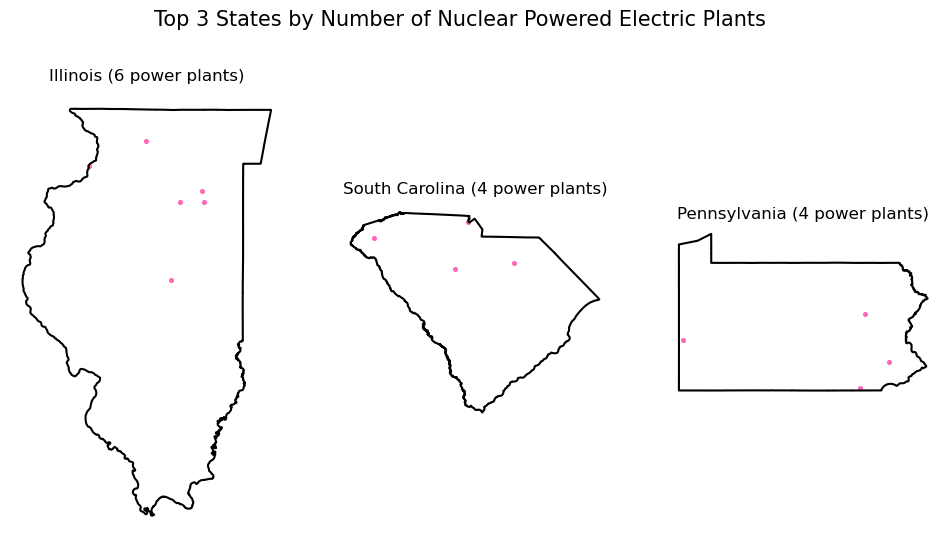

In [68]:
top3_states('nuclear')

In [60]:
def test(source, power_plants):
    source_only = power_plants[power_plants['primsource'] == source]
    top3 = source_only.groupby('state').size().sort_values(ascending=False)
    
    return top3

In [61]:
test('wind', power_plants)

state
Texas             215
Minnesota         122
Iowa              121
California        107
Oklahoma           64
Illinois           50
Oregon             49
Kansas             47
North Dakota       39
Nebraska           34
Michigan           34
Colorado           32
Idaho              32
New York           32
New Mexico         29
Pennsylvania       26
Wyoming            25
Washington         23
South Dakota       23
Ohio               22
Massachusetts      20
Maine              20
Indiana            20
Montana            19
Rhode Island       19
Missouri           14
Wisconsin          12
Hawaii              8
West Virginia       8
Arizona             6
Vermont             5
Utah                5
New Hampshire       5
Maryland            5
Alaska              4
Puerto Rico         2
Tennessee           2
New Jersey          2
North Carolina      1
Nevada              1
Virginia            1
Delaware            1
Connecticut         1
dtype: int64